# Evaluación del Índice Multidimensional de Vulnerabilidad Laboral y Estructural (IVLE)

En este notebook verificamos matemáticamente la robustez del modelo de Inteligencia Artificial que diagnostica la vulnerabilidad de los hogares, validando el desempeño del clasificador multiclase (LightGBM).

In [1]:
import sys
import os
sys.path.append('../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from dashboard.src.data_processor import DataProcessor
from dashboard.src.model_trainer import ModelTrainer

## 1. Carga y Fusión de Datos (Data Fusion ENOE + ENIGH)

In [2]:
processor = DataProcessor(dataset_path='../Dataset')
df_enigh, _ = processor.load_enigh_data()
df_enoe, _ = processor.load_enoe_data()

df_enigh_clean = processor.clean_enigh_data(df_enigh)
df_enoe_clean = processor.clean_enoe_data(df_enoe)

# Fusión de Datos
df_fused = processor.fuse_enoe_enigh(df_enigh_clean, df_enoe_clean)
print(f"Total de hogares fusionados: {len(df_fused)}")

Total de hogares fusionados: 91414


## 2. Construcción del IVLE (Target) mediante PCA y GMM
Aquí recreamos la lógica algorítmica para extraer el espacio latente y agrupar a la población en 5 estratos.

In [3]:
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import MinMaxScaler

df = df_fused.copy()
df['tasa_dependencia'] = df['menores'] / df['tot_integ'].clip(lower=1)
df['dependencia_financiera'] = df['transfer'] / df['ing_cor'].replace(0, 1)
df['ing_cor_pc'] = df['ing_cor'] / df['tot_integ'].clip(lower=1)

cols_ivle = ['ing_cor_pc', 'dependencia_financiera', 'educa_jefe', 'tasa_dependencia', 'riesgo_informalidad_entorno']
df[cols_ivle] = df[cols_ivle].fillna(df[cols_ivle].median())

scaler = MinMaxScaler()
X_ivle = pd.DataFrame(scaler.fit_transform(df[cols_ivle]), columns=cols_ivle, index=df.index)
X_ivle['ing_cor_pc'] = 1 - X_ivle['ing_cor_pc']
X_ivle['educa_jefe'] = 1 - X_ivle['educa_jefe']

pca = PCA(n_components=1, random_state=42)
ivle_continuo = pca.fit_transform(X_ivle).flatten()
if np.corrcoef(ivle_continuo, X_ivle['dependencia_financiera'])[0, 1] < 0:
    ivle_continuo = -ivle_continuo

ivle_continuo = MinMaxScaler((0, 100)).fit_transform(ivle_continuo.reshape(-1, 1)).flatten()
df['ivle_score'] = ivle_continuo

gmm = GaussianMixture(n_components=5, covariance_type='tied', random_state=42)
clases_gmm = gmm.fit_predict(ivle_continuo.reshape(-1, 1))

centros = gmm.means_.flatten()
orden_clases = np.argsort(centros)
mapa_clases = {orden_clases[i]: i for i in range(5)}
df['ivle_clase'] = np.vectorize(mapa_clases.get)(clases_gmm)

print("Distribución del IVLE (0=Muy Baja, 4=Muy Alta):")
print(df['ivle_clase'].value_counts().sort_index())

C:\Users\jonat\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\jonat\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\jonat\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jonat\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^

Distribución del IVLE (0=Muy Baja, 4=Muy Alta):
ivle_clase
0    17083
1    40549
2    14928
3    11407
4     7447
Name: count, dtype: int64


## 3. Entrenamiento y Evaluación del Clasificador Multiclase (LightGBM)
Realizamos un split 80-20 para asegurar que el modelo se prueba con datos no vistos y evaluamos el reporte de métricas.

In [4]:
from sklearn.pipeline import Pipeline
import lightgbm as lgb

if 'negocio' in df.columns and 'con_negocio' not in df.columns:
    df['con_negocio'] = (df['negocio'] > 0).astype(int)
    
feats = ['edad_jefe', 'educa_jefe', 'menores', 'tot_integ', 'ing_cor', 'ingtrab', 'transfer', 'con_negocio', 'riesgo_informalidad_entorno']
X = df[feats]
y = df['ivle_clase']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

trainer = ModelTrainer()
prepro = trainer._get_preprocessor(['edad_jefe', 'menores', 'tot_integ', 'ing_cor', 'ingtrab', 'transfer', 'riesgo_informalidad_entorno'], 
                                    ['educa_jefe'], [], ['con_negocio'])

pipe_eval = Pipeline([
    ('pre', prepro),
    ('clf', lgb.LGBMClassifier(
        objective='multiclass',
        num_class=5,
        random_state=42, 
        verbose=-1,
        class_weight='balanced',
        n_estimators=150
    ))
])

pipe_eval.fit(X_train, y_train)
y_pred = pipe_eval.predict(X_test)
y_proba = pipe_eval.predict_proba(X_test)

print("\n--- REPORTE DE CLASIFICACIÓN MULTICLASE ---")
print(classification_report(y_test, y_pred))

C:\Users\jonat\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\jonat\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- REPORTE DE CLASIFICACIÓN MULTICLASE ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3417
           1       0.99      0.97      0.98      8110
           2       0.91      0.94      0.93      2986
           3       0.92      0.94      0.93      2281
           4       0.95      0.97      0.96      1489

    accuracy                           0.96     18283
   macro avg       0.95      0.96      0.96     18283
weighted avg       0.97      0.96      0.96     18283



## 4. Matriz de Confusión
Observamos los aciertos y las confusiones. En problemas multiclase ordinales, los errores suelen concentrarse en clases vecinas.

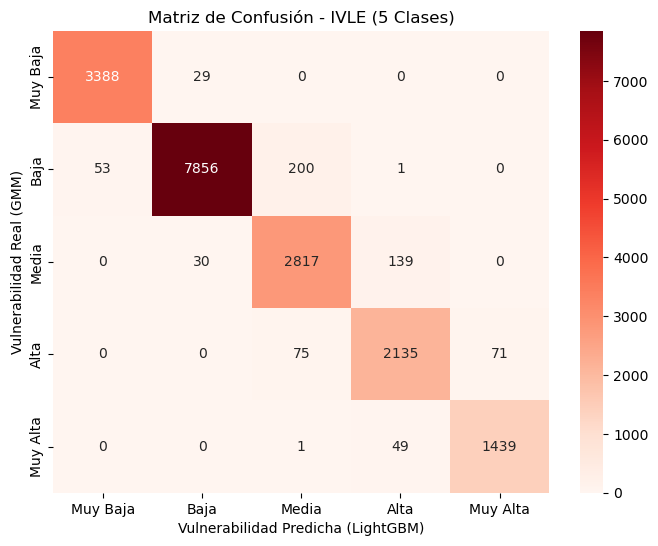

In [5]:
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Muy Baja', 'Baja', 'Media', 'Alta', 'Muy Alta'], 
            yticklabels=['Muy Baja', 'Baja', 'Media', 'Alta', 'Muy Alta'])
plt.title("Matriz de Confusión - IVLE (5 Clases)")
plt.ylabel("Vulnerabilidad Real (GMM)")
plt.xlabel("Vulnerabilidad Predicha (LightGBM)")
plt.show()